<a href="https://colab.research.google.com/github/jhuarancca/ChiefAIOfficerProgram/blob/main/CAIO_Tipos_de_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd

# Datos de ejemplo: Universidades y su desempeño
data = {
    'universidad': ['U. Lima', 'U. Andes', 'U. Chile', 'U. Nacional', 'U. Católica', 'U. Pacífico', 'U. Sao Paulo', 'U. Buenos Aires', 'UNFV'],
    'pais': ['Perú', 'Colombia', 'Chile', 'Perú', 'Chile', 'Perú', 'Brasil', 'Argentina','Perú'],
    'egresados': [1200, 850, 1500, 3000, 1100, 700, 4500, 3800,1],
    'empleabilidad_score': [85, 78, 82, 65, 88, 92, 75, 70,90]
}
df = pd.DataFrame(data)

# --- Univariante No Gráfica ---
print("--- Estadísticas de Egresados ---")
print(df['egresados'].describe())

print("\n--- Frecuencia de Países (Variables Categóricas) ---")
print(df['pais'].value_counts())

--- Estadísticas de Egresados ---
count       9.000000
mean     1850.111111
std      1540.953475
min         1.000000
25%       850.000000
50%      1200.000000
75%      3000.000000
max      4500.000000
Name: egresados, dtype: float64

--- Frecuencia de Países (Variables Categóricas) ---
pais
Perú         4
Chile        2
Colombia     1
Brasil       1
Argentina    1
Name: count, dtype: int64


In [8]:
# --- Univariante No Gráfica ---
print("--- Estadísticas de Empleabilidad ---")
print(df['empleabilidad_score'].describe())

print("\n--- Frecuencia de Universidades (Variables Categóricas) ---")
print(df['universidad'].value_counts())

--- Estadísticas de Empleabilidad ---
count     9.000000
mean     80.555556
std       9.275116
min      65.000000
25%      75.000000
50%      82.000000
75%      88.000000
max      92.000000
Name: empleabilidad_score, dtype: float64

--- Frecuencia de Universidades (Variables Categóricas) ---
universidad
U. Lima            1
U. Andes           1
U. Chile           1
U. Nacional        1
U. Católica        1
U. Pacífico        1
U. Sao Paulo       1
U. Buenos Aires    1
UNFV               1
Name: count, dtype: int64


Agregue Estadisticas de Empleabilidad


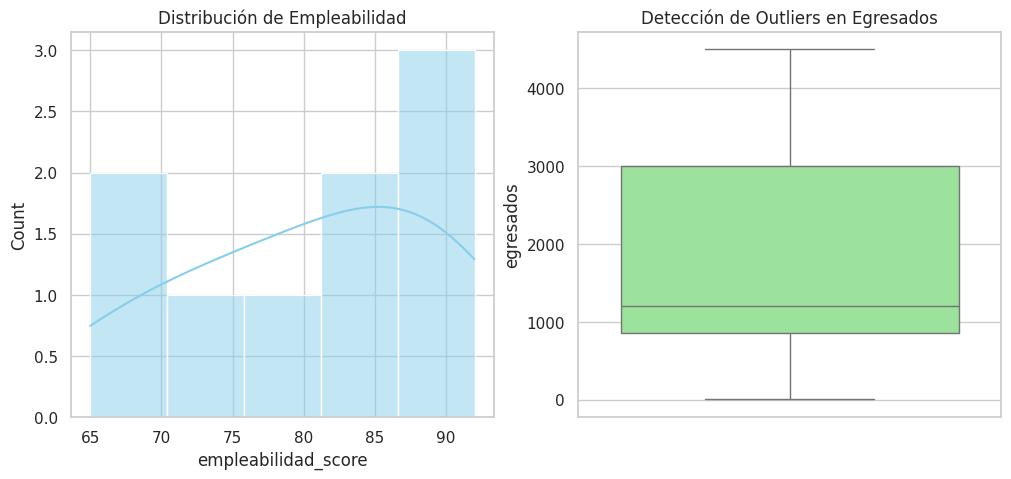

In [9]:
# --- EDA Univariante Gráfico ---
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")

# Histograma y Boxplot para la tasa de empleabilidad
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['empleabilidad_score'], kde=True, color='skyblue')
plt.title('Distribución de Empleabilidad')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['egresados'], color='lightgreen')
plt.title('Detección de Outliers en Egresados')

plt.show()

In [11]:
# --- Multivariante No Gráfica ---

# 1. Matriz de Correlación
print("--- Matriz de Correlación ---")
print(df[['egresados', 'empleabilidad_score']].corr())

# 2. Agrupación
print("\n--- Promedio de Empleabilidad por País ---")
print(df.groupby('pais')['empleabilidad_score'].mean().sort_values(ascending=False))

# 2. Agrupación
print("\n--- Promedio de Egresados por País ---")
print(df.groupby('pais')['egresados'].mean().sort_values(ascending=False))

--- Matriz de Correlación ---
                     egresados  empleabilidad_score
egresados             1.000000            -0.789229
empleabilidad_score  -0.789229             1.000000

--- Promedio de Empleabilidad por País ---
pais
Chile        85.0
Perú         83.0
Colombia     78.0
Brasil       75.0
Argentina    70.0
Name: empleabilidad_score, dtype: float64

--- Promedio de Egresados por País ---
pais
Brasil       4500.00
Argentina    3800.00
Chile        1300.00
Perú         1225.25
Colombia      850.00
Name: egresados, dtype: float64


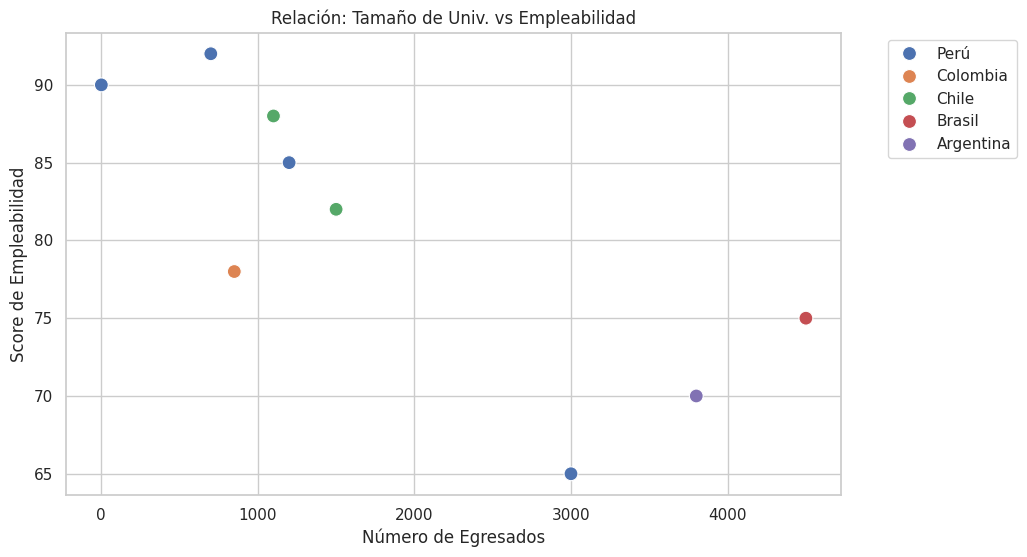

In [12]:
# --- Multivariante Gráfico ---

plt.figure(figsize=(10, 6))

# Scatter plot: Relación entre Egresados y Empleabilidad, coloreado por País
sns.scatterplot(data=df, x='egresados', y='empleabilidad_score', hue='pais', s=100)

plt.title('Relación: Tamaño de Univ. vs Empleabilidad')
plt.xlabel('Número de Egresados')
plt.ylabel('Score de Empleabilidad')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()
